# 예측을 해봅시당~~

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

**Params**

In [43]:
#data slicing
start = 1440 * 1 #일차
end = start + 1440 * 1 #일간

#LSTM config
units = 128

#learning config
epochs=10
batch_size=32

In [44]:
g_resv_flow = pd.read_csv('../data/rawdata/53.csv')
g_resv_flow.columns = ['id', 'time', 'g_resv_flow', 'drop']
del g_resv_flow['id']
del g_resv_flow['drop']
g_resv_flow.head()

,time,g_resv_flow
0,2023-01-01 00:02:00,22
1,2023-01-01 00:03:00,23
2,2023-01-01 00:04:00,22
3,2023-01-01 00:05:00,22
4,2023-01-01 00:06:00,24


In [45]:
g_resv_flow_temp = g_resv_flow[start:end]

time = g_resv_flow_temp['time']
time = pd.to_datetime(time)
g_resv_flow_temp['time'] = time


**Preprocessing (IQR)**

In [46]:
# 0. Setup Frame
frame = 180

# 1. Calculate Quartiles
Q1 = g_resv_flow_temp['g_resv_flow'].rolling(frame).quantile(0.25) #쿼타일을 여기서 만들면 좀 그럴듯 
Q3 = g_resv_flow_temp['g_resv_flow'].rolling(frame).quantile(0.75)
IQR = Q3 - Q1

# 2. Define Bounds
lower_bound = Q1 - 0.1 * IQR
upper_bound = Q3 + 0.1 * IQR

# 3. Identify Outliers
outlier_lower = (g_resv_flow_temp['g_resv_flow'] < lower_bound) 
outlier_upper = (g_resv_flow_temp['g_resv_flow'] > upper_bound)

# 4. Clean (Capping)
# We limit the flow to the upper and lower bounds
g_resv_flow_temp['cleaned_g_resv_flow'] = g_resv_flow_temp['g_resv_flow'].clip(lower=lower_bound, upper=upper_bound, axis=0)

#print(f"IQR Bounds: {lower_bound:.2f} to {upper_bound:.2f}")
print(f"rows replaced upper: {outlier_upper.sum()}")
print(f"rows replaced lower: {outlier_lower.sum()}")
g_resv_flow_temp.head()

rows replaced upper: 486
rows replaced lower: 289


,time,g_resv_flow,cleaned_g_resv_flow
1440,2023-01-02 00:03:00,22,22.0
1441,2023-01-02 00:04:00,24,24.0
1442,2023-01-02 00:05:00,22,22.0
1443,2023-01-02 00:06:00,24,24.0
1444,2023-01-02 00:07:00,24,24.0


**Check Data After Processing**

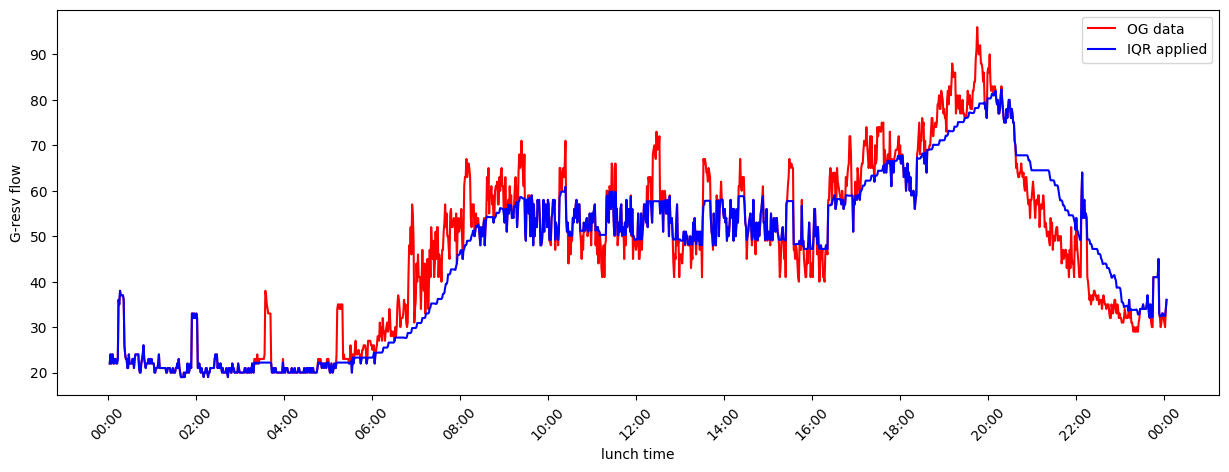

In [47]:
fig, ax = plt.subplots(figsize=(15,5))

#=========g_resv_flow
#=========g_resv_flow
#=========g_resv_flow

ax.plot(time, g_resv_flow_temp['g_resv_flow'], label='OG data', color='red')
ax.plot(time, g_resv_flow_temp['cleaned_g_resv_flow'], label='IQR applied', color='blue')

#=========misc config
#=========misc config
#=========misc config
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('lunch time')
ax.set_ylabel('G-resv flow')
ax.legend()

plt.xticks(rotation=45)

plt.show()

**Data Normalization**

In [48]:
scaler = MinMaxScaler(feature_range=(0,1))

column_to_normalize = g_resv_flow_temp.columns[-1]
g_resv_flow_temp['normalized_flow'] = scaler.fit_transform(g_resv_flow_temp[[column_to_normalize]])


In [49]:
g_resv_flow_temp.head()

,time,g_resv_flow,cleaned_g_resv_flow,normalized_flow
1440,2023-01-02 00:03:00,22,22.0,0.047393
1441,2023-01-02 00:04:00,24,24.0,0.078989
1442,2023-01-02 00:05:00,22,22.0,0.047393
1443,2023-01-02 00:06:00,24,24.0,0.078989
1444,2023-01-02 00:07:00,24,24.0,0.078989


**Sliding Window Dataset**

In [50]:
def create_sliding_windows(data, window_size=60, lead_time=1, forecast_size=10):
    stop_index = len(data) - window_size - forecast_size
    X = [data[i:i+window_size] for i in range(stop_index)]
    y = [data[i+window_size : i+window_size+forecast_size] for i in range(stop_index)]

    return np.array(X), np.array(y)

In [53]:
g_resv_flow_values = g_resv_flow_temp['normalized_flow'].values
X,y = create_sliding_windows(g_resv_flow_values)
print(g_resv_flow_values.shape, X.shape[0], X.shape[1])

X = X.reshape((X.shape[0], X.shape[1],1))
print(X.shape)
print(f"total windowed samples: {len(X)}")

(1440,) 1370 60
(1370, 60, 1)
total windowed samples: 1370


**Train Test Split**

In [30]:
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1096
Testing samples: 274


**Univariate LSTM with MSE Loss**

In [31]:
#define model
model = Sequential([
    #1층
    LSTM(units=units, activation='relu', input_shape=(60,1), return_sequences=True),
    Dropout(0.2),
    #2층
    LSTM(units=int(units/2), activation='relu', return_sequences=False),
    Dropout(0.2),

    #Output
    Dense(10)
])

#use MSE for loss
model.compile(optimizer='adam', loss='mse')

#train
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size, #train sample/batch size = step per epoch
    validation_data=(X_test,y_test),
    verbose=1
)

Epoch 1/10


c:\Users\user\miniconda3\envs\mypy\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0790 - val_loss: 0.0351
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0144 - val_loss: 0.0042
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0103 - val_loss: 0.0062
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0086 - val_loss: 0.0047
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0079 - val_loss: 0.0050
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0086 - val_loss: 0.0078
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0073 - val_loss: 0.0051
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0076 - val_loss: 0.0050
Epoch 9/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0068 - val_loss: 0.0052
Epoch 10/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0071 - val_loss: 0.0063


**Evaluation**

In [32]:
y_pred_normalized = model.predict(X_test)

y_pred_original = scaler.inverse_transform(y_pred_normalized.reshape(-1,1).reshape(y_pred_normalized.shape))
y_test_original = scaler.inverse_transform(y_test.reshape(-1,1).reshape(y_test.shape))

mae = mean_absolute_error(y_test_original, y_pred_original)
print(f"--- Evaluation Result ---")
print(f"Mean Absolute Error: {mae:.2f} m^3/hour")
print(f"Interpretation: On average, our 10-minute prediction is off by {mae:.2f} m^3/hour.")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
--- Evaluation Result ---
Mean Absolute Error: 4.28 m^3/hour
Interpretation: On average, our 10-minute prediction is off by 4.28 m^3/hour.


**Plot**

(10,)


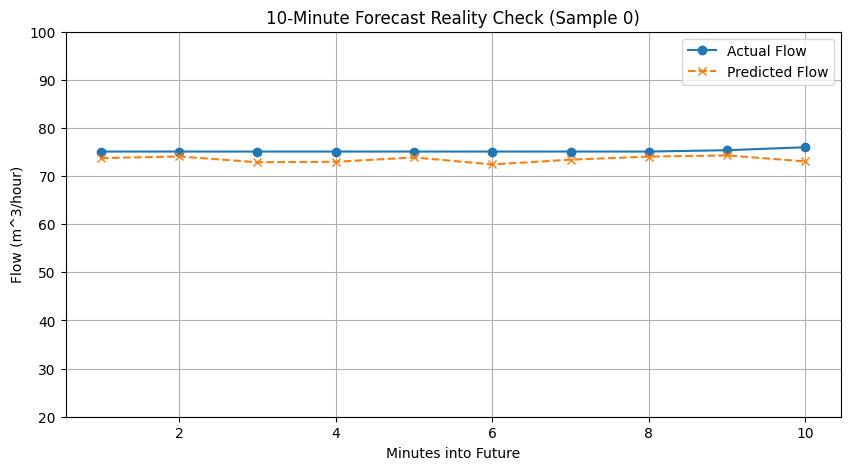

In [33]:
sample_idx = 10 * 0
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), y_test_original[sample_idx], label='Actual Flow', marker='o')
plt.plot(range(1, 11), y_pred_original[sample_idx], label='Predicted Flow', marker='x', linestyle='--')
plt.title(f"10-Minute Forecast Reality Check (Sample {sample_idx})")
plt.xlabel("Minutes into Future")
plt.ylabel("Flow (m^3/hour)")
plt.legend()
plt.grid(True)

# Fix the y-axis from 0 to 100
plt.ylim(20, 100) 

print(y_test_original[sample_idx].shape)

plt.show()